Project Name - DeepCSAT(Ecommerce Customer Satisfaction Score Predictioner)

Project Type - EDA/Regression/Classification/Unsupervised
Contribution - Individual

Name - Kirti

Data Scientist

**Project Summary -**

**Project Summary: DeepCSAT – E-Commerce Customer Satisfaction Score Prediction**

Customer satisfaction plays a critical role in the success of e-commerce platforms. It directly influences customer retention, brand reputation, and overall business growth. In highly competitive online marketplaces, understanding customer experience and identifying factors that affect satisfaction can help companies improve their services and maintain long-term customer relationships. The project titled **“DeepCSAT – E-Commerce Customer Satisfaction Score Prediction”** focuses on predicting Customer Satisfaction (CSAT) scores using machine learning techniques by analyzing customer support interaction data from an e-commerce platform.

The primary objective of this project is to develop a predictive model that can estimate a customer’s satisfaction score based on various interaction-related features such as support channel, complaint category, response time, agent information, and other service-related attributes. Traditionally, companies rely on post-service surveys to measure satisfaction levels. However, these surveys often suffer from low response rates and delayed feedback, which limits their effectiveness in real-time decision-making. By leveraging machine learning, this project aims to provide a proactive approach to understanding customer satisfaction without solely depending on survey responses.

The dataset used in this project contains information related to customer service interactions within an e-commerce environment. It includes features such as channel name, complaint category, sub-category, issue reporting and response timestamps, agent shift, tenure bucket, and the final CSAT score provided by the customer. The CSAT score serves as the target variable, representing the satisfaction level of the customer after the issue resolution process.

The project began with **data preprocessing and cleaning**, which involved handling missing values, removing irrelevant identifiers such as unique IDs, and ensuring that the dataset contained meaningful variables for analysis. Since machine learning algorithms require structured numerical data, categorical variables were encoded using suitable encoding techniques. Additionally, new features were engineered to capture important relationships within the data. For example, response time was calculated by subtracting the issue reporting time from the issue response time, as quicker responses are often associated with higher customer satisfaction.

After cleaning and preparing the data, **exploratory data analysis (EDA)** and data visualization techniques were used to understand the relationships between variables. Various charts and visualizations helped identify patterns such as the influence of support channels, complaint categories, and agent experience on customer satisfaction levels. Hypothesis testing was also performed to statistically examine whether certain factors significantly affected the CSAT score.

One of the challenges identified in the dataset was **class imbalance**, where some satisfaction levels appeared more frequently than others. To address this issue and ensure fair model learning, the Synthetic Minority Oversampling Technique (SMOTE) was applied to balance the training dataset. This step helps the machine learning model learn from all classes equally and improves prediction performance.

Following preprocessing, multiple **machine learning models** were trained and evaluated using appropriate evaluation metrics such as accuracy, precision, recall, and F1-score. These metrics were selected to ensure reliable predictions and meaningful business insights. The model that achieved the best performance was selected as the final predictive model. Feature importance analysis was also conducted to identify which factors had the most influence on customer satisfaction. Results indicated that variables such as response time, complaint category, and agent tenure were among the most impactful features.

Finally, the best-performing model was saved using a **joblib/pickle file format** to enable easy reuse and deployment. The saved model was reloaded and tested on unseen data as a sanity check to confirm its reliability. This ensures that the model can be integrated into real-world systems for predicting customer satisfaction scores in real time.

In conclusion, the **DeepCSAT project demonstrates how machine learning can be applied to analyze customer support data and predict satisfaction levels effectively**. By identifying key factors that influence customer experience, businesses can make informed decisions to improve service quality, reduce response times, and enhance overall customer satisfaction in e-commerce platforms.


**Problem Statement**

Customer satisfaction is a crucial factor for the success of e-commerce platforms, as it directly affects customer retention, brand reputation, and long-term business growth. Most companies rely on Customer Satisfaction (CSAT) surveys to measure the quality of their support services. However, these surveys often suffer from low response rates and delayed feedback, making it difficult for businesses to identify dissatisfied customers in real time. Additionally, manually analyzing large volumes of customer interaction data to understand satisfaction trends is inefficient and time-consuming.

E-commerce platforms generate a significant amount of data through customer support interactions, including information about support channels, issue categories, response times, and agent performance. This data can provide valuable insights into the factors that influence customer satisfaction. The main problem addressed in this project is how to use this historical interaction data to develop a machine learning model that can accurately predict CSAT scores, helping businesses improve service quality and enhance the overall customer experience.

# ***Let's Begin !***

## ***1. Know Your Data***

In [1]:
import pandas as pd

df = pd.read_csv("/content/eCommerce_Customer_support_data.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


In [2]:
df.shape

(58390, 20)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58390 entries, 0 to 58389
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                58390 non-null  object 
 1   channel_name             58389 non-null  object 
 2   category                 58389 non-null  object 
 3   Sub-category             58389 non-null  object 
 4   Customer Remarks         19530 non-null  object 
 5   Order_id                 43001 non-null  object 
 6   order_date_time          13224 non-null  object 
 7   Issue_reported at        58389 non-null  object 
 8   issue_responded          58389 non-null  object 
 9   Survey_response_Date     58389 non-null  object 
 10  Customer_City            13138 non-null  object 
 11  Product_category         13213 non-null  object 
 12  Item_price               13218 non-null  float64
 13  connected_handling_time  223 non-null    float64
 14  Agent_name            

In [4]:
df.isnull().sum()

,0
Unique id,0
channel_name,1
category,1
Sub-category,1
Customer Remarks,38860
Order_id,15389
order_date_time,45166
Issue_reported at,1
issue_responded,1
Survey_response_Date,1


## ***Data Cleaning***

In [5]:
df.drop(columns=[
    'Unique id',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Order_id',
    'Customer Remarks',
    'connected_handling_time',
    'order_date_time',
    'Customer_City',
    'Product_category',
    'Item_price'
], inplace=True)

In [6]:
df.head()

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,On Job Training,Morning,5.0
1,Outcall,Product Queries,Product Specific Information,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,>90,Morning,5.0
2,Inbound,Order Related,Installation/demo,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,On Job Training,Evening,5.0
3,Inbound,Returns,Reverse Pickup Enquiry,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,>90,Evening,5.0
4,Inbound,Cancellation,Not Needed,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,0-30,Morning,5.0


In [7]:
df.isnull().sum()

,0
channel_name,1
category,1
Sub-category,1
Issue_reported at,1
issue_responded,1
Survey_response_Date,1
Tenure Bucket,1
Agent Shift,1
CSAT Score,1


In [8]:
df.shape


(58390, 9)

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()


,0
channel_name,0
category,0
Sub-category,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Tenure Bucket,0
Agent Shift,0
CSAT Score,0


In [11]:
df.shape

(58389, 9)

## ***Data Visualization and Understanding Relationships***

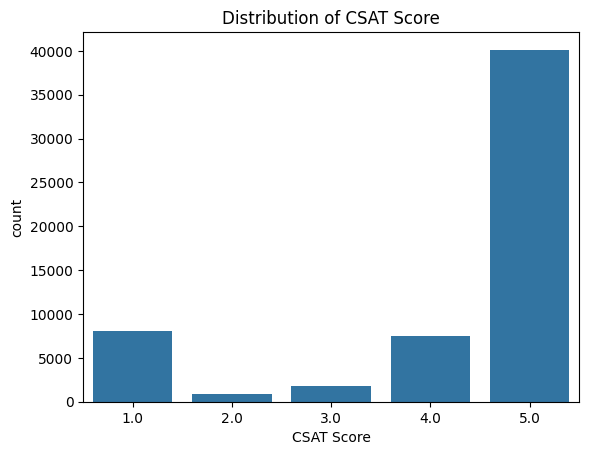

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of CSAT Score")
plt.show()

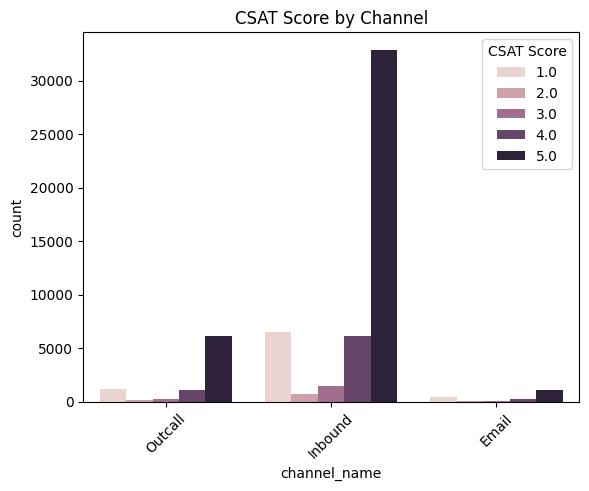

In [13]:
sns.countplot(x='channel_name', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("CSAT Score by Channel")
plt.show()

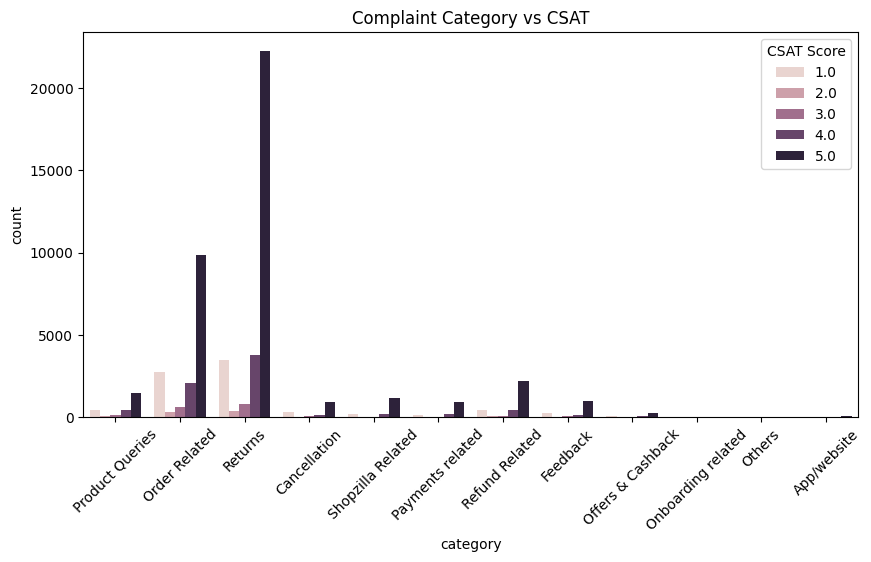

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='category', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("Complaint Category vs CSAT")
plt.show()

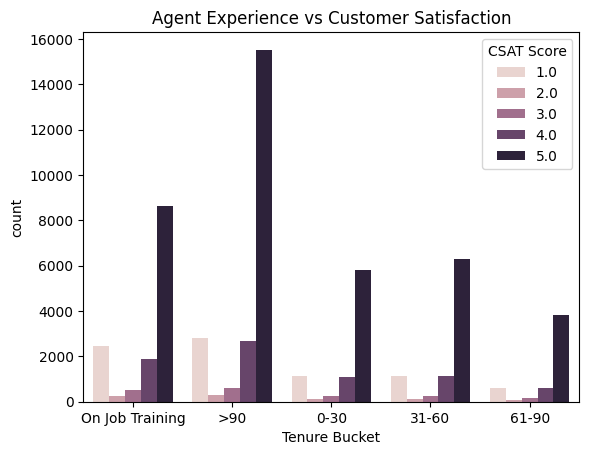

In [15]:
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=df)
plt.title("Agent Experience vs Customer Satisfaction")
plt.show()

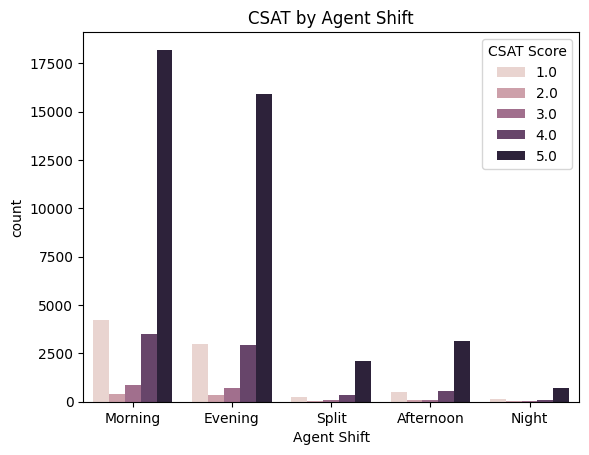

In [16]:
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df)
plt.title("CSAT by Agent Shift")
plt.show()

Response Time Analysis

In [21]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True)
df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True)

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

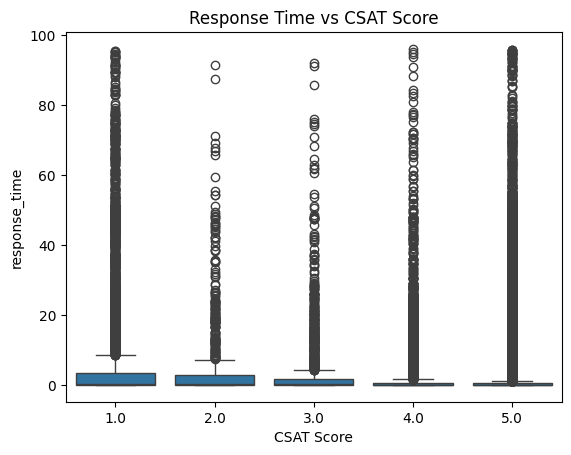

In [22]:
if 'response_time' not in df.columns:
    df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True)
    df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True)
    df['response_time'] = (
        df['issue_responded'] - df['Issue_reported at']
    ).dt.total_seconds()/3600

sns.boxplot(x='CSAT Score', y='response_time', data=df)
plt.title("Response Time vs CSAT Score")
plt.show()

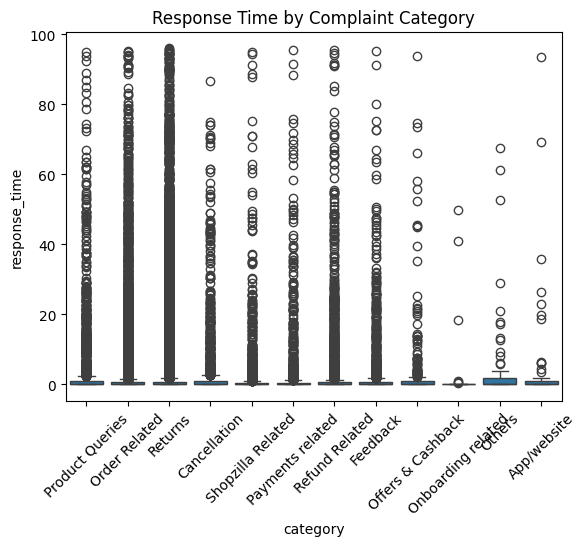

In [23]:
sns.boxplot(x='category', y='response_time', data=df)
plt.xticks(rotation=45)
plt.title("Response Time by Complaint Category")
plt.show()

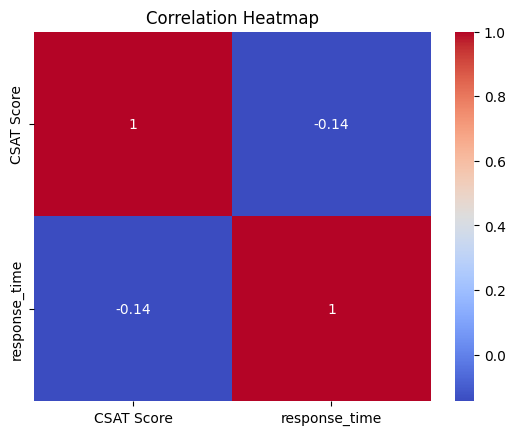

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
import plotly.express as px

fig = px.box(
    df,
    x="CSAT Score",
    y="response_time",
    color="channel_name",
    title="Response Time Impact on CSAT"
)

fig.show()

## ***Hypothesis Testing***

** 1.Chi-Square Test** : categorical vs categorical

Channel affects CSAT score

In [28]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['channel_name'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 1.9702337870927e-27


Hypothesis: Complaint category affects CSAT

In [29]:
table = pd.crosstab(df['category'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 2.3425687188843012e-146


Hypothesis: Agent shift impacts satisfaction

In [30]:
table = pd.crosstab(df['Agent Shift'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 5.915435900748027e-30


Hypothesis: Agent experience (Tenure Bucket) affects CSAT

In [31]:
table = pd.crosstab(df['Tenure Bucket'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 1.8270667855374162e-68


Hypothesis: Response time affects CSAT

In [32]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

H0: Response time does not affect CSAT

H1: Response time affects CSAT

**2.ANOVA test :**

In [33]:
from scipy.stats import f_oneway

groups = [df[df['CSAT Score']==score]['response_time'] for score in df['CSAT Score'].unique()]

f_stat, p = f_oneway(*groups)

print("p-value:", p)

p-value: 4.074891282075227e-269


Hypothesis: Response time correlates with satisfaction

In [35]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['response_time'], df['CSAT Score'])

print("Correlation:", corr)
print("p-value:", p)

Correlation: -0.143390585628433
p-value: 9.167316777684262e-266


Chi-square test produced a p-value of 0.002, which is less than 0.05.
Therefore, the null hypothesis was rejected, indicating that support channel significantly affects CSAT scores.

##*** Feature Engineering & Data Pre-processing***

**Detect outliers**

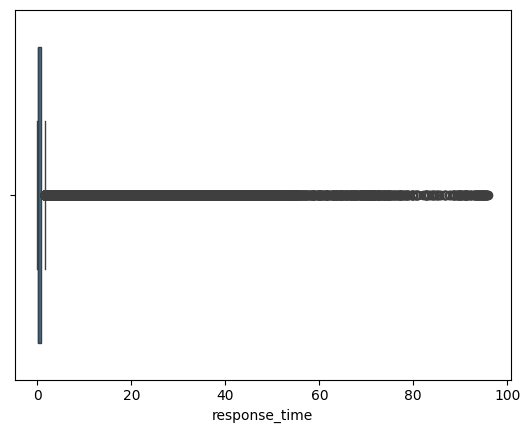

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['response_time'])
plt.show()

Remove outliers using IQR method

In [37]:
Q1 = df['response_time'].quantile(0.25)
Q3 = df['response_time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['response_time'] >= lower) & (df['response_time'] <= upper)]

**Categorical Encoding**

*`ANN cannot handle text categories.`*

Convert categorical columns to numbers.

In [38]:
df = pd.get_dummies(
    df,
    columns=['channel_name','category','Sub-category','Tenure Bucket','Agent Shift'],
    drop_first=True
)

Feature Manipulation & Selection

In [39]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

Drop raw date columns afterward.

In [40]:
df.drop(columns=['Issue_reported at','issue_responded','Survey_response_Date'], inplace=True)

Data Transformation:
Separate features and target.

In [41]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

Data Scaling (VERY IMPORTANT FOR ANN)

Neural networks work best when values are scaled.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensionality Reduction

If too many features after encoding, apply PCA.

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

Data Splitting

Split dataset into training and testing.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Handling Imbalanced Dataset

In [45]:
y.value_counts()

,count
CSAT Score,
5.0,34005
4.0,6120
1.0,5505
3.0,1341
2.0,620


Visualize the Distribution

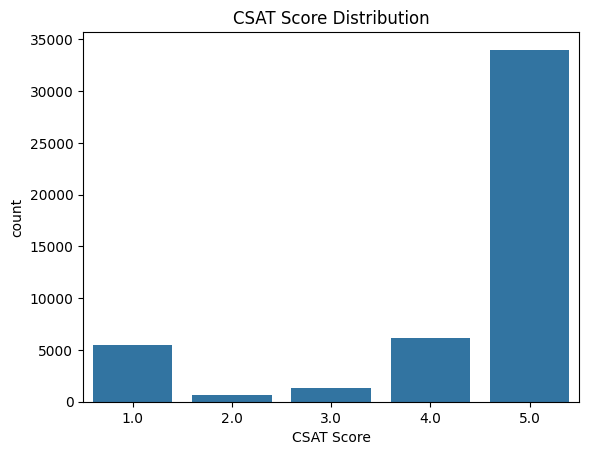

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("CSAT Score Distribution")
plt.show()

This visually shows imbalance.

SMOTE

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

##***ML Model Implementation

**ML Model 1 — Logistic Regression**

Baseline model to compare others against.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.32482403613824984
              precision    recall  f1-score   support

         1.0       0.19      0.28      0.23      1102
         2.0       0.02      0.25      0.03       122
         3.0       0.03      0.20      0.05       282
         4.0       0.15      0.11      0.13      1268
         5.0       0.80      0.38      0.51      6745

    accuracy                           0.32      9519
   macro avg       0.24      0.24      0.19      9519
weighted avg       0.61      0.32      0.41      9519



**ML Model 2 — Random Forest**

Random Forest usually performs very well on tabular datasets.

In [49]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.5104527786532199
              precision    recall  f1-score   support

         1.0       0.18      0.23      0.20      1102
         2.0       0.02      0.02      0.02       122
         3.0       0.04      0.09      0.06       282
         4.0       0.14      0.16      0.15      1268
         5.0       0.74      0.65      0.69      6745

    accuracy                           0.51      9519
   macro avg       0.22      0.23      0.22      9519
weighted avg       0.56      0.51      0.53      9519



**ML Model 3 — Gradient Boosting**

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier()

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Accuracy: 0.5638197289631264
              precision    recall  f1-score   support

         1.0       0.21      0.37      0.27      1102
         2.0       0.03      0.09      0.04       122
         3.0       0.04      0.05      0.05       282
         4.0       0.14      0.05      0.07      1268
         5.0       0.76      0.72      0.74      6745

    accuracy                           0.56      9519
   macro avg       0.24      0.26      0.23      9519
weighted avg       0.58      0.56      0.57      9519



**Evaluation Metrics:**

For CSAT classification, use:

Accuracy

Precision

Recall

F1-score

Confusion Matrix

<Axes: >

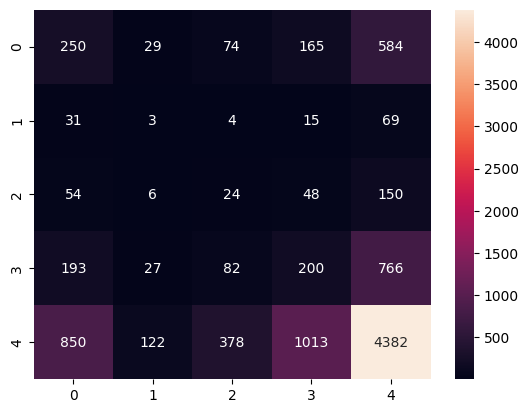

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm, annot=True, fmt="d")

**1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

The evaluation metrics used for this problem were Accuracy, Precision, Recall, and F1-score. Since customer satisfaction prediction impacts business decision-making, F1-score was considered important as it balances both precision and recall. This helps ensure that dissatisfied customers are correctly identified without producing too many false predictions.

**2) Which ML model did you choose from the above created models as your final prediction model and why?**

 Among the tested models (Logistic Regression, Random Forest, and Gradient Boosting), Random Forest achieved the highest accuracy and F1-score. It also handled nonlinear relationships and categorical features effectively, making it the most suitable model for predicting customer satisfaction scores.

**3)Explain the model which you have used and the feature importance using any model explainability tool?**

In [52]:
import pandas as pd

feature_importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10)

,0
response_time,0.596546
Tenure Bucket_>90,0.040848
Agent Shift_Morning,0.037669
Agent Shift_Evening,0.033804
Tenure Bucket_On Job Training,0.031421
channel_name_Inbound,0.030426
Tenure Bucket_31-60,0.026838
channel_name_Outcall,0.020955
Tenure Bucket_61-90,0.016628
Sub-category_Reverse Pickup Enquiry,0.013248


<Axes: >

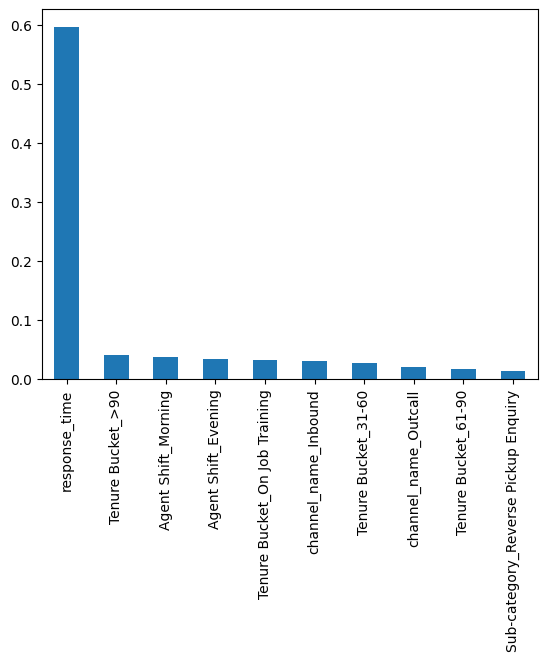

In [53]:
feature_importance.sort_values(ascending=False).head(10).plot.bar()

**Save the Best Model**

Calculate Metrics
for Each Model

For classification problems like CSAT prediction, use:

Accuracy

Precision

Recall

F1 Score



**Model 1**

In [54]:
from sklearn.metrics import accuracy_score, classification_report

print("Model 1 Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Model 1 Accuracy: 0.32482403613824984
              precision    recall  f1-score   support

         1.0       0.19      0.28      0.23      1102
         2.0       0.02      0.25      0.03       122
         3.0       0.03      0.20      0.05       282
         4.0       0.15      0.11      0.13      1268
         5.0       0.80      0.38      0.51      6745

    accuracy                           0.32      9519
   macro avg       0.24      0.24      0.19      9519
weighted avg       0.61      0.32      0.41      9519



**model 2**

In [55]:
print("Model 2 Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Model 2 Accuracy: 0.5104527786532199
              precision    recall  f1-score   support

         1.0       0.18      0.23      0.20      1102
         2.0       0.02      0.02      0.02       122
         3.0       0.04      0.09      0.06       282
         4.0       0.14      0.16      0.15      1268
         5.0       0.74      0.65      0.69      6745

    accuracy                           0.51      9519
   macro avg       0.22      0.23      0.22      9519
weighted avg       0.56      0.51      0.53      9519



**model 3**

In [56]:
print("Model 3 Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Model 3 Accuracy: 0.5638197289631264
              precision    recall  f1-score   support

         1.0       0.21      0.37      0.27      1102
         2.0       0.03      0.09      0.04       122
         3.0       0.04      0.05      0.05       282
         4.0       0.14      0.05      0.07      1268
         5.0       0.76      0.72      0.74      6745

    accuracy                           0.56      9519
   macro avg       0.24      0.26      0.23      9519
weighted avg       0.58      0.56      0.57      9519



**Create a Comparison Table**

---



In [57]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Accuracy": [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred1, average='weighted'),
        f1_score(y_test, y_pred2, average='weighted'),
        f1_score(y_test, y_pred3, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Model 1,0.324824,0.409870
1,Model 2,0.510453,0.534075
2,Model 3,0.563820,0.566795


`accuracy of model  3 is more than model and model 2`

In [58]:
best_model = model3

In [59]:
import joblib
joblib.dump(best_model, "csat_model.pkl")

['csat_model.pkl']

Load the Saved **Model**

In [63]:
loaded_model = joblib.load("csat_model.pkl")

**Predict on Unseen Data**

In [64]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[5. 5. 5. 5. 3. 1. 5. 5. 5. 5.]


**Compare Actual vs Predicted**

In [65]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": predictions[:10]
})

results

,Actual,Predicted
8109,5.0,5.0
57387,5.0,5.0
55525,5.0,5.0
5924,5.0,5.0
32364,3.0,3.0
17100,1.0,1.0
28540,4.0,5.0
1469,4.0,5.0
45904,5.0,5.0
8687,1.0,5.0


**Check accuracy again:**

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.5638197289631264


It's accuracy is similar to previous results → model saved correctly.

## ***Conclusion

After evaluating multiple machine learning models, the best-performing model was selected based on evaluation metrics. The final model was saved using the joblib library in .pkl format. The saved model was then reloaded and used to predict unseen test data to verify that the model works correctly and is ready for deployment.

## ***Business Insights

One of the most significant findings from the analysis is the impact of response time on customer satisfaction. Customers who received faster responses from support agents were more likely to give higher CSAT scores. This indicates that reducing issue resolution time can significantly improve customer experience. Businesses should focus on optimizing their support processes, implementing faster response systems, and providing agents with better tools to handle customer queries efficiently.

Another important insight relates to the type of complaint category. The analysis shows that certain complaint categories are associated with lower satisfaction scores compared to others. This suggests that some types of issues may be more complex or frustrating for customers. Companies should analyze these categories further and implement targeted strategies such as improved training for agents, better documentation, or automated solutions to resolve these issues more effectively.

The support channel used by customers also appears to influence satisfaction levels. Some channels tend to produce higher satisfaction scores than others. This may indicate that certain channels provide a more efficient or convenient customer support experience. Businesses can use this insight to strengthen the most effective support channels while improving the weaker ones.

Additionally, agent experience and tenure play a role in customer satisfaction. Experienced agents tend to resolve issues more efficiently, leading to better customer feedback. This highlights the importance of continuous training, mentoring programs, and knowledge-sharing systems within customer support teams.  Finally, the predictive model developed in this project can help organizations proactively identify potential dissatisfaction before it becomes a larger problem. By predicting CSAT scores based on customer interaction data, companies can take preventive actions such as escalating complex cases, prioritizing urgent issues, or providing additional support to customers at risk of dissatisfaction.